# HOTEL BOOKING ANALYSIS

## Needed Libraries

In [1]:
%%capture test
# Get needed requeriments
%pip install --upgrade plotly;
%pip install --upgrade seaborn;
%pip install --upgrade openpyxl;

In [2]:
#Libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Import/Extract

In [3]:
current_path = os.getcwd()
hotel_bookings = pd.read_excel(current_path + "/hotel_bookings.xlsx")

hotel_bookings.head()

,booking_id,hotel,is_canceled,lead_time,arrival_date_week_number,booking_date,arrival_date,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,is_repeated_guest,previous_cancellations,assigned_room_type,booking_changes,deposit_type,agent,company,customer_type,required_car_parking_spaces,total_of_special_requests
0,1,Resort Hotel,0,342,27,2017-07-24,2018-07-01,1,0,0,...,0,0,C,3,No Deposit,NaN,NaN,No Contract (Single),0,0
1,2,Resort Hotel,0,737,27,2016-06-24,2018-07-01,1,0,0,...,0,0,C,4,No Deposit,NaN,NaN,No Contract (Single),0,0
2,3,Resort Hotel,0,7,27,2018-06-24,2018-07-01,1,0,1,...,0,0,C,0,No Deposit,NaN,NaN,No Contract (Single),0,0
3,4,Resort Hotel,0,13,27,2018-06-18,2018-07-01,1,0,1,...,0,0,A,0,No Deposit,304.0,NaN,No Contract (Single),0,0
4,5,Resort Hotel,0,14,27,2018-06-17,2018-07-01,1,0,2,...,0,0,A,0,No Deposit,240.0,NaN,No Contract (Single),0,1


## Data Preprocessing

### Data Shape

In [4]:
hotel_bookings.shape

(119390, 26)

### Separate the bookings into different hotels

In [5]:
#Check the type of hotels

hotel_bookings['hotel'].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

In [6]:
resort = hotel_bookings['hotel']=='Resort Hotel'

resort_hotel = hotel_bookings[resort]

resort_hotel = resort_hotel.copy()

resort_hotel.head().T

,0,1,2,3,4
booking_id,1,2,3,4,5
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel
is_canceled,0,0,0,0,0
lead_time,342,737,7,13,14
arrival_date_week_number,27,27,27,27,27
booking_date,2017-07-24 00:00:00,2016-06-24 00:00:00,2018-06-24 00:00:00,2018-06-18 00:00:00,2018-06-17 00:00:00
arrival_date,2018-07-01 00:00:00,2018-07-01 00:00:00,2018-07-01 00:00:00,2018-07-01 00:00:00,2018-07-01 00:00:00
arrival_date_day_of_month,1,1,1,1,1
stays_in_weekend_nights,0,0,0,0,0
stays_in_week_nights,0,0,1,1,2


In [7]:
resort_hotel['hotel'].unique()

array(['Resort Hotel'], dtype=object)

In [8]:
resort_hotel.shape

(40060, 26)

In [9]:
city_hotel = hotel_bookings[~resort]

city_hotel = city_hotel.copy()

city_hotel.head()

,booking_id,hotel,is_canceled,lead_time,arrival_date_week_number,booking_date,arrival_date,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,is_repeated_guest,previous_cancellations,assigned_room_type,booking_changes,deposit_type,agent,company,customer_type,required_car_parking_spaces,total_of_special_requests
40060,40061,City Hotel,0,6,27,2018-06-25,2018-07-01,1,0,2,...,0,0,A,0,No Deposit,6.0,NaN,No Contract (Single),0,0
40061,40062,City Hotel,1,88,27,2018-04-04,2018-07-01,1,0,4,...,0,0,A,0,No Deposit,9.0,NaN,No Contract (Single),0,1
40062,40063,City Hotel,1,65,27,2018-04-27,2018-07-01,1,0,4,...,0,0,A,0,No Deposit,9.0,NaN,No Contract (Single),0,1
40063,40064,City Hotel,1,92,27,2018-03-31,2018-07-01,1,2,4,...,0,0,A,0,No Deposit,9.0,NaN,No Contract (Single),0,2
40064,40065,City Hotel,1,100,27,2018-03-24,2018-07-02,2,0,2,...,0,0,A,0,No Deposit,9.0,NaN,No Contract (Single),0,1


### Check data info

In [10]:
resort_hotel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40060 entries, 0 to 40059
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   booking_id                   40060 non-null  int64         
 1   hotel                        40060 non-null  object        
 2   is_canceled                  40060 non-null  int64         
 3   lead_time                    40060 non-null  int64         
 4   arrival_date_week_number     40060 non-null  int64         
 5   booking_date                 40060 non-null  datetime64[ns]
 6   arrival_date                 40060 non-null  datetime64[ns]
 7   arrival_date_day_of_month    40060 non-null  int64         
 8   stays_in_weekend_nights      40060 non-null  int64         
 9   stays_in_week_nights         40060 non-null  int64         
 10  adults                       40060 non-null  int64         
 11  children                     40060 non-null  f

## Descriptive Analysis

In [11]:
def desc_analysis(hotel_data):
    result = hotel_data.describe().T
    return result

In [12]:
desc_analysis(resort_hotel)

,count,mean,min,25%,50%,75%,max,std
booking_id,40060.0,20030.5,1.0,10015.75,20030.5,30045.25,40060.0,11564.470229
is_canceled,40060.0,0.277634,0.0,0.0,0.0,1.0,1.0,0.447837
lead_time,40060.0,92.675686,0.0,10.0,57.0,155.0,737.0,97.285315
arrival_date_week_number,40060.0,27.140864,1.0,16.0,28.0,38.0,53.0,14.005441
booking_date,40060,2019-05-15 12:02:41.757363968,2016-06-24 00:00:00,2018-11-15 00:00:00,2019-04-26 00:00:00,2019-12-07 00:00:00,2020-08-31 00:00:00,NaN
arrival_date,40060,2019-08-16 04:15:41.068397312,2018-07-01 00:00:00,2019-02-14 00:00:00,2019-08-19 00:00:00,2020-03-05 00:00:00,2020-08-31 00:00:00,NaN
arrival_date_day_of_month,40060.0,15.821243,1.0,8.0,16.0,24.0,31.0,8.883708
stays_in_weekend_nights,40060.0,1.189815,0.0,0.0,1.0,2.0,19.0,1.147812
stays_in_week_nights,40060.0,3.128732,0.0,1.0,3.0,5.0,50.0,2.461329
adults,40060.0,1.867149,0.0,2.0,2.0,2.0,55.0,0.697285


In [12]:
desc_analysis(resort_hotel)

,count,mean,min,25%,50%,75%,max,std
booking_id,40060.0,20030.5,1.0,10015.75,20030.5,30045.25,40060.0,11564.470229
is_canceled,40060.0,0.277634,0.0,0.0,0.0,1.0,1.0,0.447837
lead_time,40060.0,92.675686,0.0,10.0,57.0,155.0,737.0,97.285315
arrival_date_week_number,40060.0,27.140864,1.0,16.0,28.0,38.0,53.0,14.005441
booking_date,40060,2019-05-15 12:02:41.757363968,2016-06-24 00:00:00,2018-11-15 00:00:00,2019-04-26 00:00:00,2019-12-07 00:00:00,2020-08-31 00:00:00,NaN
arrival_date,40060,2019-08-16 04:15:41.068397312,2018-07-01 00:00:00,2019-02-14 00:00:00,2019-08-19 00:00:00,2020-03-05 00:00:00,2020-08-31 00:00:00,NaN
arrival_date_day_of_month,40060.0,15.821243,1.0,8.0,16.0,24.0,31.0,8.883708
stays_in_weekend_nights,40060.0,1.189815,0.0,0.0,1.0,2.0,19.0,1.147812
stays_in_week_nights,40060.0,3.128732,0.0,1.0,3.0,5.0,50.0,2.461329
adults,40060.0,1.867149,0.0,2.0,2.0,2.0,55.0,0.697285


### This tells us:

#### lead_time

- 40,060 bookings have a lead_time value.
- The average booking was made 92.7 days before arrival.
- The shortest lead time was 0 days — same-day booking.
- 25% of bookings were made 10 days or less before arrival.
- 50% were made 57 days or less before arrival.
- 75% were made 155 days or less before arrival.
- The longest lead time was 737 days.
- The relatively large std of 97.3 tells us that lead times vary considerably.

## Exploratory Data Analysis

### 1. Monthly Bookings and Cancellations

In [13]:
#Create arrival Month

resort_hotel['booking_month'] = resort_hotel['booking_date'].dt.month

In [14]:
#check the new column booking_month

resort_hotel.head()

,booking_id,hotel,is_canceled,lead_time,arrival_date_week_number,booking_date,arrival_date,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,previous_cancellations,assigned_room_type,booking_changes,deposit_type,agent,company,customer_type,required_car_parking_spaces,total_of_special_requests,booking_month
0,1,Resort Hotel,0,342,27,2017-07-24,2018-07-01,1,0,0,...,0,C,3,No Deposit,NaN,NaN,No Contract (Single),0,0,7
1,2,Resort Hotel,0,737,27,2016-06-24,2018-07-01,1,0,0,...,0,C,4,No Deposit,NaN,NaN,No Contract (Single),0,0,6
2,3,Resort Hotel,0,7,27,2018-06-24,2018-07-01,1,0,1,...,0,C,0,No Deposit,NaN,NaN,No Contract (Single),0,0,6
3,4,Resort Hotel,0,13,27,2018-06-18,2018-07-01,1,0,1,...,0,A,0,No Deposit,304.0,NaN,No Contract (Single),0,0,6
4,5,Resort Hotel,0,14,27,2018-06-17,2018-07-01,1,0,2,...,0,A,0,No Deposit,240.0,NaN,No Contract (Single),0,1,6


In [15]:
#summary

monthly_summary = resort_hotel.groupby(['booking_month', 'is_canceled']).size().reset_index(name='Count')


monthly_summary

,booking_month,is_canceled,Count
0,1,0,4268
1,1,1,1627
2,2,0,3363
3,2,1,1150
4,3,0,2683
5,3,1,906
6,4,0,1922
7,4,1,813
8,5,0,1844
9,5,1,816


In [16]:
#Pivot the data

pivot_df = monthly_summary.pivot(index='booking_month', columns='is_canceled', values = 'Count').fillna(0)

pivot_df

is_canceled,0,1
booking_month,,
1,4268,1627
2,3363,1150
3,2683,906
4,1922,813
5,1844,816
6,1789,812
7,1919,889
8,1844,636
9,1945,945


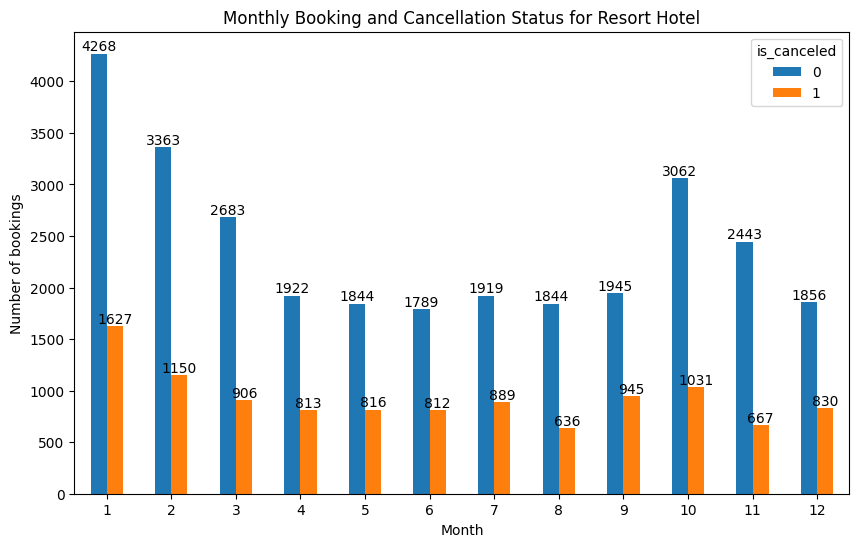

In [17]:
ax = pivot_df.plot(kind='bar', figsize=(10,6))

#Customise labels
plt.xlabel('Month')
plt.ylabel('Number of bookings')
plt.title('Monthly Booking and Cancellation Status for Resort Hotel')
plt.xticks(rotation=0)

# Add data labels to the bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge')


plt.show()

Conclusion (This will be replaced by AI)
- Bookings are always high at the beginning of the year, but decrease towards the middle of the month, and continue the upward trend again.
- Facilities improvement, new marketing tactics.

### 2. Repeated Guests Analysis

In [20]:
def rep_guest(hotel_data, hotel_name):
    #summary of the data
    repeated_guest_summary = hotel_data['is_repeated_guest'].value_counts()

    # Define labels
    labels = ['Not Repeated Guest', 'Repeated Guest']
    
    # Get sizes (counts) in order
    sizes = repeated_guest_summary.sort_index().values
    
    # Plotting
    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title(f'Distribution of Repeated Guests at {hotel_name}')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

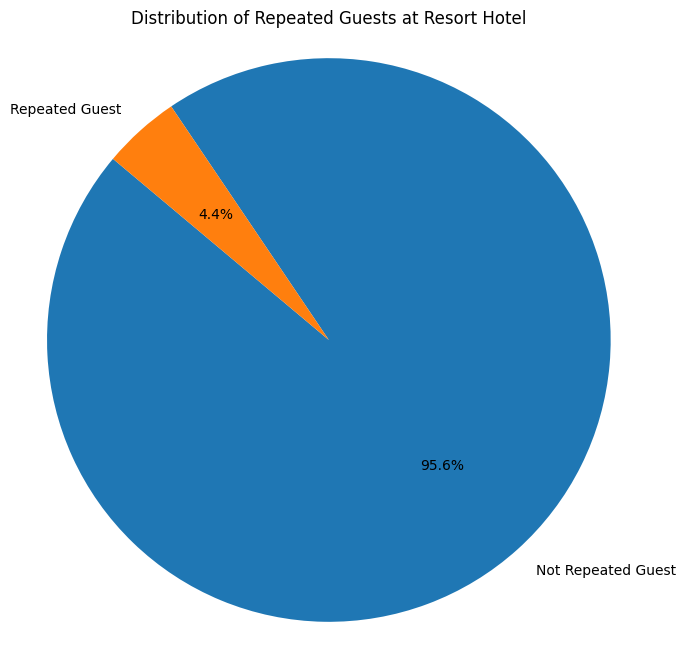

In [21]:
rep_guest(resort_hotel, 'Resort Hotel')

Conclusion (This will be replaced by AI)
- Over 95% are new customer, which means most of the guests don't come back.
- Look into customer retention techniques, like club card, referral bonus.
- Also investigate customer service experience.

### 3. Traveler Type

In [23]:
def travel_type(hotel_data, hotel_name):
    #family booking
    hotel_data['is_family_booking'] = (hotel_data['adults'] + hotel_data['children']+ hotel_data['babies'])>1

    #summary
    traveler_type_summary = hotel_data['is_family_booking'].value_counts()

    #plot
    labels = ['Single', 'Family']
    
    # Get sizes (counts) in order
    sizes = traveler_type_summary.sort_index().values
    
    # Plotting
    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title(f'Distribution of Traveler Type at {hotel_name}')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()
    return traveler_type_summary

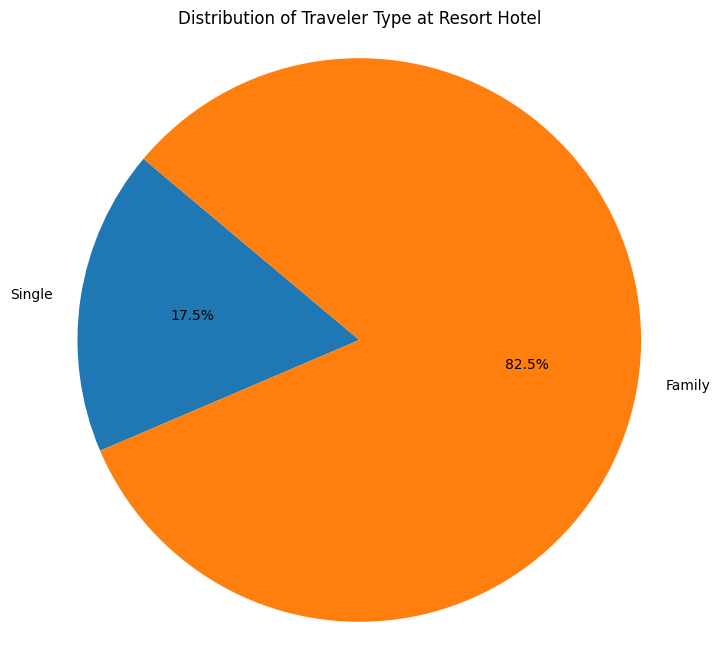

is_family_booking
True     33034
False     7026
Name: count, dtype: int64

In [24]:
#resort hotel

travel_type(resort_hotel,'Resort Hotel')

Conclusion (This will be replaced by AI)
- We have families visiting the hotel compare to single people.
- Are families the targeted customers?

### 4. Breakdown of Guest Origins by Country